# Analse presolve annotation effects for benchmark models

In [ ]:
from pathlib import Path

K = 7 

LIBRARY = "MIPLIB"
MODEL_NAME = "unitcal_7"

MPS_ORIG = Path(f'/data/energy-system-preprocessing/models/benchmarks/{LIBRARY}/{MODEL_NAME}/original.mps')
MPS_PRE  = Path(f'/data/energy-system-preprocessing/presolve/papilo/benchmarks/{LIBRARY}/{MODEL_NAME}/reduced.mps')

ANN_DIR      = Path('/data/energy-system-preprocessing/annotations_benchmarks')
GDX_ORIG     = ANN_DIR / 'original'  / f'{MODEL_NAME}.gdx'
GDX_PRE      = ANN_DIR / 'presolved' / f'{MODEL_NAME}.gdx'

ANN_DIR.mkdir(parents=True, exist_ok=True)
(ANN_DIR / 'original').mkdir(exist_ok=True)
(ANN_DIR / 'presolved').mkdir(exist_ok=True)

BLOCKS_BASE           = Path('/data/energy-system-preprocessing/blocks')
BLOCKS_ORIG = BLOCKS_BASE / MODEL_NAME / 'original'
BLOCKS_PRE  = BLOCKS_BASE / MODEL_NAME / 'reduced'

MAX_MPI_PROCS = 8  # cap MPI processes to avoid OOM


In [21]:
import sys
from pathlib import Path

PROJECT_ROOT = Path('../..').resolve()
sys.path.insert(0, str(PROJECT_ROOT))

import polars as pl
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.gridspec import GridSpec

from src.detection import (
    annotate_mps,
    read_annotation,
    align_partitions,
    partition_similarity,
)
from src.detection.visualisation import (
    transfer_partition,
    plot_partition,
    compute_partition_stats,
    render_stats,
    read_integer_col_names,
)

## Step 1 — Annotate original model

In [22]:
import multiprocessing as mp

def _worker(args):
    import os, sys
    devnull = os.open(os.devnull, os.O_WRONLY)
    os.dup2(devnull, 1)
    os.dup2(devnull, 2)
    os.close(devnull)
    mps_in, k, gdx_out, project_root = args
    sys.path.insert(0, project_root)
    from src.detection.annotation import annotate_mps
    annotate_mps(mps_in, k=K, output_gdx=gdx_out)


if GDX_ORIG.exists():
    print(f'Original GDX already exists, skipping: {GDX_ORIG}')
else:
    print(f'Annotating original (k={K})...')
    p = mp.Process(target=_worker, args=((str(MPS_ORIG), K, str(GDX_ORIG), str(PROJECT_ROOT)),))
    p.start()
    p.join()
    if p.exitcode == 0:
        print('Done.')
    else:
        print(f'FAILED (exitcode={p.exitcode})')

Original GDX already exists, skipping: /data/energy-system-preprocessing/annotations_benchmarks/original/irish-electricity.gdx


## Step 2 — Annotate PaPILO-presolved model

In [23]:
if GDX_PRE.exists():
    print(f'Presolved GDX already exists, skipping: {GDX_PRE}')
else:
    print(f'Annotating presolved (k={K})...')
    p = mp.Process(target=_worker, args=((str(MPS_PRE), K, str(GDX_PRE), str(PROJECT_ROOT)),))
    p.start()
    p.join()
    if p.exitcode == 0:
        print('Done.')
    else:
        print(f'FAILED (exitcode={p.exitcode})')

Presolved GDX already exists, skipping: /data/energy-system-preprocessing/annotations_benchmarks/presolved/irish-electricity.gdx


## Step 3 — Compare partition assignments

Align surviving variables/constraints by name and compute ARI / NMI / purity.

In [24]:
cols_orig, rows_orig = read_annotation(GDX_ORIG)
cols_pre,  rows_pre  = read_annotation(GDX_PRE)

alignment = align_partitions(cols_orig, rows_orig, cols_pre, rows_pre)
sim       = partition_similarity(alignment)

print('Irish Electricity — partition similarity (original vs PaPILO presolved)\n')
print(f"  Variables  : {alignment.n_cols_a} → {alignment.n_surviving_cols} surviving "
      f"({alignment.col_survival_rate:.1%} survival)")
print(f"  Constraints: {alignment.n_rows_a} → {alignment.n_surviving_rows} surviving "
      f"({alignment.row_survival_rate:.1%} survival)")
print()
print(f"  {'Metric':<18} {'Variables':>12} {'Constraints':>14}")
print(f"  {'-'*44}")
print(f"  {'ARI':<18} {sim.col_ari:>12.4f} {sim.row_ari:>14.4f}")
print(f"  {'NMI':<18} {sim.col_nmi:>12.4f} {sim.row_nmi:>14.4f}")
print(f"  {'Purity':<18} {sim.col_purity:>12.4f} {sim.row_purity:>14.4f}")

Irish Electricity — partition similarity (original vs PaPILO presolved)

  Variables  : 61729 → 29803 surviving (48.3% survival)
  Constraints: 104260 → 46035 surviving (44.2% survival)

  Metric                Variables    Constraints
  --------------------------------------------
  ARI                      0.3534         0.4168
  NMI                      0.6186         0.6958
  Purity                   0.4922         0.5528


## Step 4 — Similarity metric plots

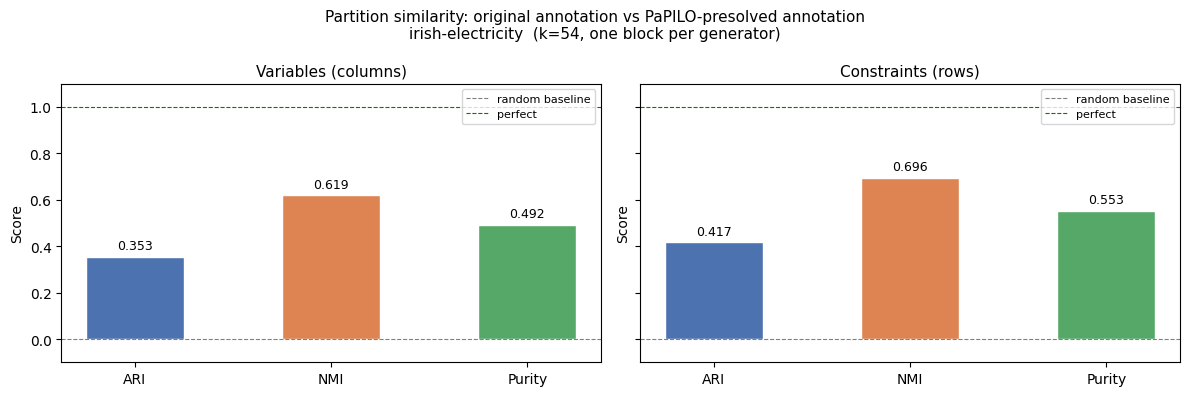

In [25]:
metrics = ['ARI', 'NMI', 'Purity']
col_vals = [sim.col_ari, sim.col_nmi, sim.col_purity]
row_vals = [sim.row_ari, sim.row_nmi, sim.row_purity]

x = range(len(metrics))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

for ax, vals, kind in [
    (axes[0], col_vals, 'Variables (columns)'),
    (axes[1], row_vals, 'Constraints (rows)'),
]:
    bars = ax.bar(metrics, vals, color=['#4C72B0', '#DD8452', '#55A868'], edgecolor='white', width=0.5)
    ax.axhline(0, color='grey', linestyle='--', linewidth=0.8, label='random baseline')
    ax.axhline(1, color='green', linestyle='--', linewidth=0.8, label='perfect')
    ax.set_ylim(-0.1, 1.1)
    ax.set_title(kind, fontsize=11)
    ax.set_ylabel('Score')
    ax.legend(fontsize=8)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9)

fig.suptitle(
    'Partition similarity: original annotation vs PaPILO-presolved annotation\n'
    'irish-electricity  (k=54, one block per generator)',
    fontsize=11,
)
plt.tight_layout()
plt.show()

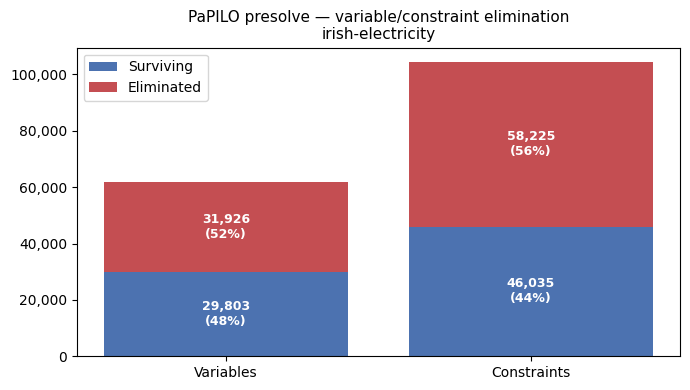

In [ ]:
categories = ['Variables', 'Constraints']
survived   = [alignment.n_surviving_cols,  alignment.n_surviving_rows]
eliminated = [alignment.n_cols_a - alignment.n_surviving_cols,
              alignment.n_rows_a  - alignment.n_surviving_rows]

fig, ax = plt.subplots(figsize=(7, 4))
b1 = ax.bar(categories, survived,   label='Surviving',  color='#4C72B0')
b2 = ax.bar(categories, eliminated, bottom=survived,    label='Eliminated', color='#C44E52')

for bar, val, total in zip(b1, survived, [alignment.n_cols_a, alignment.n_rows_a]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() / 2,
            f'{val:,}\n({val/total:.0%})', ha='center', va='center',
            fontsize=9, color='white', fontweight='bold')
for bar, base, val, total in zip(b2, survived, eliminated, [alignment.n_cols_a, alignment.n_rows_a]):
    ax.text(bar.get_x() + bar.get_width() / 2, base + bar.get_height() / 2,
            f'{val:,}\n({val/total:.0%})', ha='center', va='center',
            fontsize=9, color='white', fontweight='bold')

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.set_title('PaPILO presolve — variable/constraint elimination\nirish-electricity', fontsize=11)
ax.legend()
plt.tight_layout()
plt.show()

## Step 5 — Side-by-side matrix visualisation.

In [ ]:
from pipstools.io import read_gdx
from pipstools.utils import get_blocks_ids

cols_orig, rows_orig = read_annotation(GDX_ORIG)

A_pre, cols_pre, rows_pre, _ = read_gdx(GDX_PRE)

int_cols_orig = read_integer_col_names(MPS_ORIG)
int_cols_pre  = read_integer_col_names(MPS_PRE)

print(f'Original  : {len(cols_orig):,} vars, {len(rows_orig):,} rows  ({len(int_cols_orig):,} integer)')
print(f'Presolved : {len(cols_pre):,} vars, {len(rows_pre):,} rows, {len(A_pre):,} nnz  ({len(int_cols_pre):,} integer)')

Original  : 61,729 vars, 104,260 rows  (9,888 integer)
Presolved : 29,803 vars, 46,035 rows, 254,118 nnz  (6,080 integer)


In [ ]:
cols_orig_on_pre, rows_orig_on_pre = transfer_partition(
    cols_pre, rows_pre,
    cols_orig, rows_orig,
)

_, orig_link_first, orig_link_last = get_blocks_ids(rows_orig, cols_orig)

orig_linking_row_names = set(
    rows_orig.filter(pl.col('partition').is_in(orig_link_last + orig_link_first))['name'].to_list()
)
orig_linking_col_names = set(
    cols_orig.filter(pl.col('partition').is_in(orig_link_first))['name'].to_list()
)

presolved_row_names = set(rows_pre['name'].to_list())
presolved_col_names = set(cols_pre['name'].to_list())

surviving_linking_rows  = orig_linking_row_names & presolved_row_names
eliminated_linking_rows = orig_linking_row_names - presolved_row_names
surviving_linking_cols  = orig_linking_col_names & presolved_col_names
eliminated_linking_cols = orig_linking_col_names - presolved_col_names

int_cols_orig_on_pre = int_cols_orig & presolved_col_names

print(f'Original linking rows : {len(surviving_linking_rows)} survived, {len(eliminated_linking_rows)} eliminated')
print(f'Original linking cols : {len(surviving_linking_cols)} survived, {len(eliminated_linking_cols)} eliminated')

Original linking rows : 1037 survived, 1175 eliminated
Original linking cols : 1 survived, 5472 eliminated


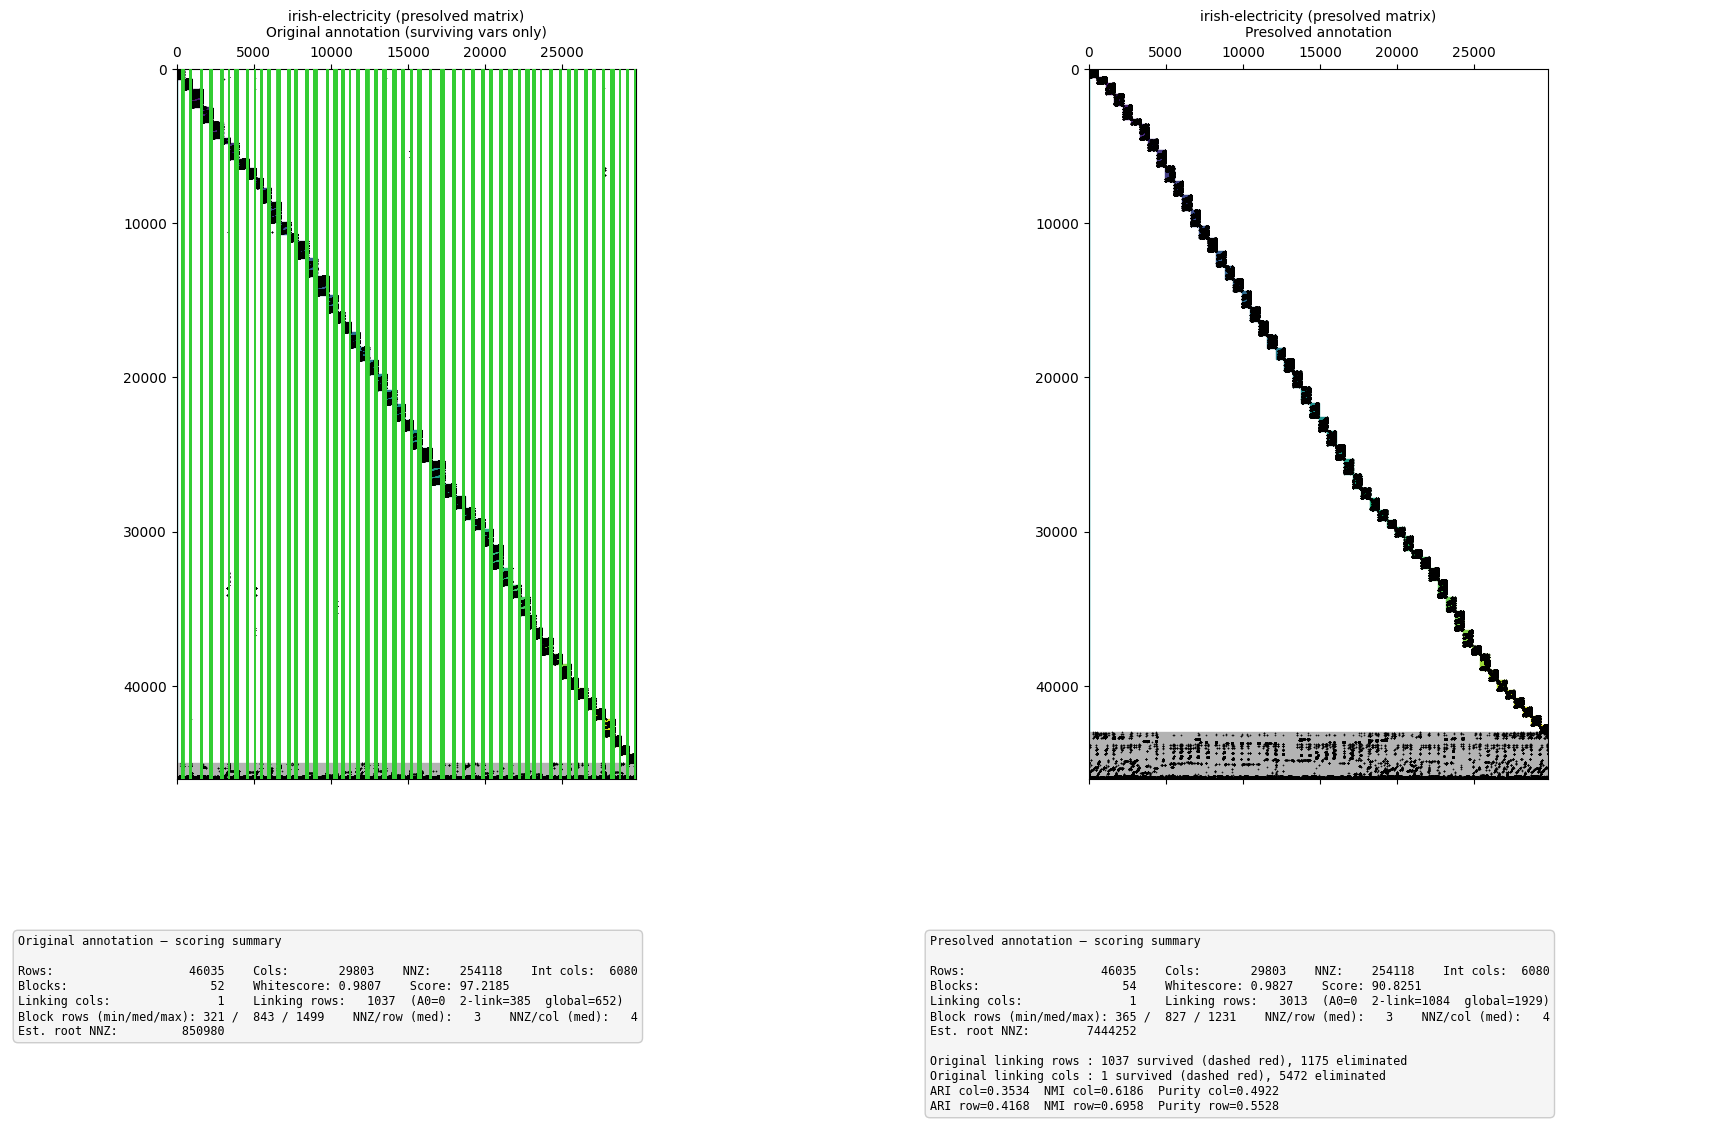

In [ ]:
COLORMAP    = 'viridis'
SKIP_BLOCKS = False

stats_orig = compute_partition_stats(A_pre, cols_orig_on_pre, rows_orig_on_pre,
                                     integer_col_names=int_cols_orig_on_pre)
stats_pre  = compute_partition_stats(A_pre, cols_pre, rows_pre,
                                     integer_col_names=int_cols_pre)

fig = plt.figure(figsize=(22, 13))
gs  = GridSpec(2, 2, figure=fig, height_ratios=[5, 1], hspace=0.35, wspace=0.15)

ax1      = fig.add_subplot(gs[0, 0])
ax2      = fig.add_subplot(gs[0, 1])
ax_info1 = fig.add_subplot(gs[1, 0])
ax_info2 = fig.add_subplot(gs[1, 1])

plot_partition(
    ax1, A_pre, cols_orig_on_pre, rows_orig_on_pre,
    colormap=COLORMAP, skip_blocks=SKIP_BLOCKS,
    title='irish-electricity (presolved matrix)\nOriginal annotation (surviving vars only)',
    integer_col_names=int_cols_orig_on_pre,
)
plot_partition(
    ax2, A_pre, cols_pre, rows_pre,
    colormap=COLORMAP, skip_blocks=SKIP_BLOCKS,
    title='irish-electricity (presolved matrix)\nPresolved annotation',
    # highlight_row_names=surviving_linking_rows,
    # highlight_col_names=surviving_linking_cols,
    # integer_col_names=int_cols_pre,
)

elim_note = [
    f'Original linking rows : {len(surviving_linking_rows)} survived (dashed red), {len(eliminated_linking_rows)} eliminated',
    f'Original linking cols : {len(surviving_linking_cols)} survived (dashed red), {len(eliminated_linking_cols)} eliminated',
    f'ARI col={sim.col_ari:.4f}  NMI col={sim.col_nmi:.4f}  Purity col={sim.col_purity:.4f}',
    f'ARI row={sim.row_ari:.4f}  NMI row={sim.row_nmi:.4f}  Purity row={sim.row_purity:.4f}',
]

render_stats(ax_info1, stats_orig, title='Original annotation — scoring summary')
render_stats(ax_info2, stats_pre,  title='Presolved annotation — scoring summary',
             extra_lines=elim_note)

plt.show()

## Step 6 — PIPS-IPM++ solve comparison

In [ ]:
import re
import subprocess
import sys
import time
from pathlib import Path

import gamspy_base

from src.config import PIPS_PATH
from src.solvers.split import split_to_blocks

PIPS_TIMEOUT = None
GMSPIPS  = PIPS_PATH / 'build' / 'gmspips'
GAMS_DIR = gamspy_base.directory

BLOCKS_ORIG.mkdir(parents=True, exist_ok=True)
BLOCKS_PRE.mkdir(parents=True, exist_ok=True)


print('[original] splitting ...')
n_orig = split_to_blocks(MPS_PRE, BLOCKS_ORIG, annotation_gdx=GDX_ORIG, transfer=True)
print(f'[original] {K} diagonal blocks')

print('[presolved] splitting ...')
n_pre = split_to_blocks(MPS_PRE, BLOCKS_PRE, annotation_gdx=GDX_PRE)
print(f'[presolved] {K} diagonal blocks')

def _run_pips(block_dir, n_diag, label):
    n_procs = min(K + 1, MAX_MPI_PROCS)
    cmd = [
        'mpirun', '-np', str(n_procs),
        str(GMSPIPS), str(K + 1),
        str(Path(block_dir) / f'block_{K}b'),
        GAMS_DIR,
        'scaleGeo',
    ]
    print(f'\n[{label}] {" ".join(cmd)}')
    t0     = time.perf_counter()
    result = subprocess.run(cmd, capture_output=True, text=True, timeout=PIPS_TIMEOUT)
    wall   = time.perf_counter() - t0
    out    = result.stdout + result.stderr
    m      = re.search(r'---Objective value:\s*([+-]?[0-9]*\.?[0-9]+(?:[eE][+-]?[0-9]+)?)', out)
    return {
        'label':      label,
        'objective':  float(m.group(1)) if m else None,
        'wall_time':  wall,
        'returncode': result.returncode,
        'stdout':     out,
    }


print('\n=== Running PIPS-IPM++ ===')
res_orig = _run_pips(BLOCKS_ORIG, n_orig, 'original annotation')
res_pre  = _run_pips(BLOCKS_PRE,  n_pre,  'presolved annotation')


[original] splitting ...


  0%|          | 0/53 [00:00<?, ?it/s]

Running HiGHS 1.14.0 (git hash: 7df0786): Copyright (c) 2026 under MIT licence terms
  transfer_partition: 0/29802 vars unmatched, 0/46034 rows unmatched (partition=0)


  0%|          | 0/55 [00:00<?, ?it/s]

[original] 54 diagonal blocks
[presolved] splitting ...


100%|██████████| 55/55 [00:01<00:00, 49.79it/s]


[presolved] 54 diagonal blocks

=== Running PIPS-IPM++ ===

[original annotation] mpirun -np 8 /homes/vm922/energy-system-preprocessing/src/solvers/PIPS-IPMpp/build/gmspips 55 /data/energy-system-preprocessing/blocks/irish-electricity/original/block_54b /homes/vm922/espenv/lib/python3.12/site-packages/gamspy_base scaleGeo

[presolved annotation] mpirun -np 8 /homes/vm922/energy-system-preprocessing/src/solvers/PIPS-IPMpp/build/gmspips 55 /data/energy-system-preprocessing/blocks/irish-electricity/reduced/block_54b /homes/vm922/espenv/lib/python3.12/site-packages/gamspy_base scaleGeo


KeyboardInterrupt: 

In [ ]:
def _fmt(val, fmt='.6g'):
    return format(val, fmt) if val is not None else 'FAILED'


def _rel_diff(a, b):
    if a is None or b is None:
        return '—'
    ref = max(abs(a), abs(b), 1e-12)
    return f'{abs(a - b) / ref * 100:.4f}%'


results = [res_orig, res_pre]

print(f'  {"Annotation":<26} {"Objective":>16} {"Wall time (s)":>14} {"Exit":>5}')
print(f'  {"-" * 64}')
for r in results:
    print(f'  {r["label"]:<26} {_fmt(r["objective"]):>16} {r["wall_time"]:>14.1f} {r["returncode"]:>5}')

print()
print(f'  Objective difference : {_rel_diff(res_orig["objective"], res_pre["objective"])}')

if res_pre['wall_time'] > 0:
    speedup = res_orig['wall_time'] / res_pre['wall_time']
    print(f'  Wall-time speedup    : {speedup:.2f}×  (presolved annotation vs original)')

for r in results:
    if r['objective'] is None:
        print(f'\n--- raw stdout/stderr [{r["label"]}] ---')
        print(r['stdout'][:3000])


  Annotation                        Objective  Wall time (s)  Exit
  ----------------------------------------------------------------
  original annotation                  FAILED            1.5   143
  presolved annotation                 FAILED            7.0     9

  Objective difference : —
  Wall-time speedup    : 0.22×  (presolved annotation vs original)

--- raw stdout/stderr [original annotation] ---
reading /data/energy-system-preprocessing/blocks/irish-electricity/original/block_54b
GAMS located at /homes/vm922/espenv/lib/python3.12/site-packages/gamspy_base
Using a total of 1 MPI processes.
Using outer BICGSTAB
Creating PIPSIpmInterface ...
Could not open GDX file /data/energy-system-preprocessing/blocks/irish-electricity/original/block_54b0.gdx (errNr=2)
GDX Error for GDX file: No such file or directory
Could not open GDX file /data/energy-system-preprocessing/blocks/irish-electricity/original/block_54b1.gdx (errNr=2)
GDX Error for GDX file: No such file or directory
Could 